# Chapter 9: Simulation of Probability Models


> **Source and scope.** This is an original computational companion to Mark M. Meerschaert, *Mathematical Modeling*, 4th ed. (Academic Press, 2013). It follows the chapter structure and reconstructs representative models in Python. It does not reproduce the textbook's prose, figures, or complete exercise sets. Equations, numerical assumptions, and example names are attributed to the book.


This notebook follows Sections 9.1-9.5: Monte Carlo simulation, Markovian simulation, analytic simulation, particle tracking, and fractional diffusion.


In [1]:
from __future__ import annotations

import platform
import warnings
from importlib.metadata import version

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy
import sympy as sp
from IPython.display import display

warnings.filterwarnings("ignore", category=RuntimeWarning)
np.set_printoptions(precision=6, suppress=True)
pd.set_option("display.precision", 6)
plt.rcParams["figure.figsize"] = (8, 4.8)

SEED = 20260731
rng = np.random.default_rng(SEED)

versions = pd.Series({
    "Python": platform.python_version(),
    "NumPy": np.__version__,
    "SciPy": scipy.__version__,
    "SymPy": sp.__version__,
    "pandas": pd.__version__,
    "Matplotlib": version("matplotlib"),
}, name="version")
display(versions.to_frame())


,version
Python,3.13.5
NumPy,2.3.5
SciPy,1.17.0
SymPy,1.14.0
pandas,2.2.3
Matplotlib,3.10.8


## 9.1 Monte Carlo: three consecutive rainy days

Each of seven days is independently rainy with probability \(p=0.5\). We estimate the probability of a run of at least three rainy days and compare it with exact enumeration.


In [2]:
from itertools import product
from scipy import stats


def has_run(sequence, run_length=3):
    count = 0
    for value in sequence:
        count = count + 1 if value else 0
        if count >= run_length:
            return True
    return False

all_weeks = list(product([0, 1], repeat=7))
exact_probability = np.mean([has_run(week) for week in all_weeks])
print(f"Exact probability: {exact_probability:.8f} = {int(exact_probability * 128)}/128")

def rainy_week_simulation(n_weeks, p=0.5):
    weather = rng.random((n_weeks, 7)) < p
    return np.array([has_run(row) for row in weather], dtype=float)

sample_sizes = np.array([100, 1_000, 10_000, 100_000])
estimates = np.array([rainy_week_simulation(int(n)).mean() for n in sample_sizes])
display(pd.DataFrame({"weeks": sample_sizes, "estimate": estimates, "absolute error": np.abs(estimates - exact_probability)}))


Exact probability: 0.36718750 = 47/128


,weeks,estimate,absolute error
0,100,0.34000,0.027187
1,1000,0.37100,0.003812
2,10000,0.36850,0.001312
3,100000,0.36815,0.000962


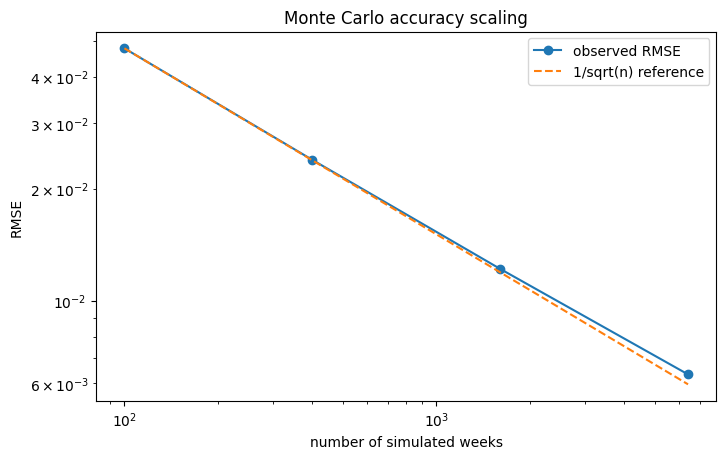

In [3]:
replications = 300
rmse = []
for n in [100, 400, 1_600, 6_400]:
    replicated_estimates = np.array([rainy_week_simulation(n).mean() for _ in range(replications)])
    rmse.append(np.sqrt(np.mean((replicated_estimates - exact_probability) ** 2)))

n_grid = np.array([100, 400, 1_600, 6_400])
plt.loglog(n_grid, rmse, marker="o", label="observed RMSE")
plt.loglog(n_grid, rmse[0] * np.sqrt(n_grid[0] / n_grid), linestyle="--", label="1/sqrt(n) reference")
plt.xlabel("number of simulated weeks")
plt.ylabel("RMSE")
plt.title("Monte Carlo accuracy scaling")
plt.legend()
plt.show()


## 9.2 Markov property and inverse-transform sampling

In the chapter's first-passage example, \(X_{n+1}\) is exponential with rate \(X_n\). The next state therefore depends only on the current state, and inverse-transform sampling gives

\[
X_{n+1}=-\frac{\log(1-U)}{X_n}.
\]


,first-passage step
count,10000.000000
mean,15.961300
std,9.548357
min,2.000000
25%,9.000000
50%,14.000000
75%,21.000000
max,70.000000


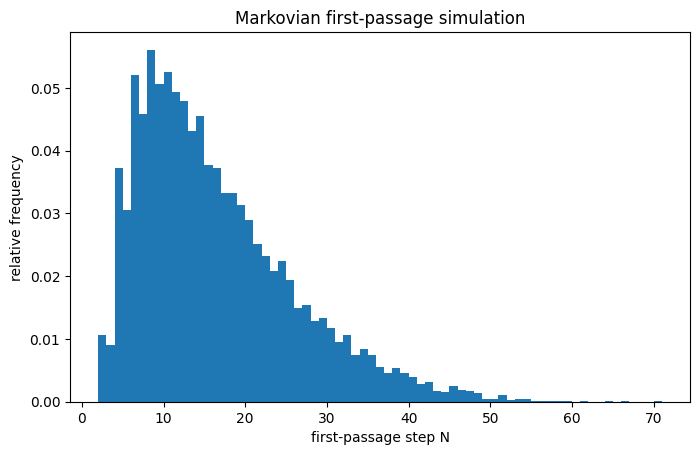

In [4]:
def first_passage_once(threshold=100.0, initial=1.0, max_steps=100_000):
    state = float(initial)
    total = 0.0
    for step in range(1, max_steps + 1):
        state = rng.exponential(1 / state)
        total += state
        if total >= threshold:
            return step
    raise RuntimeError("First-passage simulation did not terminate")

passage_times = np.array([first_passage_once() for _ in range(10_000)])
display(pd.Series(passage_times).describe().to_frame("first-passage step"))

plt.hist(passage_times, bins=np.arange(passage_times.min(), passage_times.max() + 2), density=True)
plt.xlabel("first-passage step N")
plt.ylabel("relative frequency")
plt.title("Markovian first-passage simulation")
plt.show()


## 9.3 Analytic simulation: mission-success probability

The chapter combines a binomial model for disabled aircraft with the conditional probability that at least one surviving aircraft destroys the target. This is an analytic simulation because probabilities are summed directly rather than estimated by repeated random trials.


Minimum aircraft for success probability > 0.99: 15


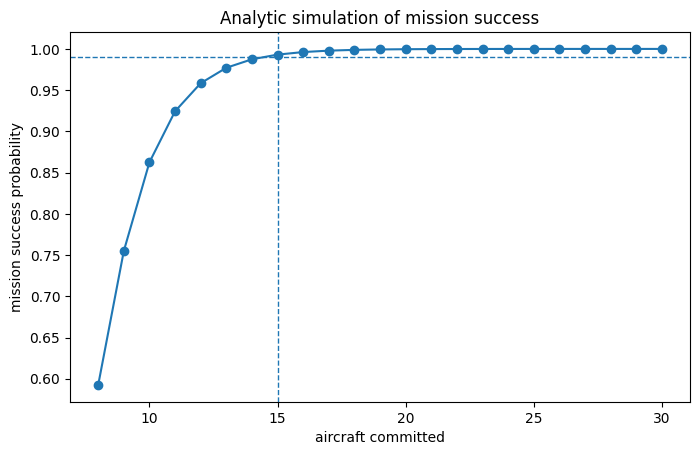

In [5]:
def mission_success(number_aircraft, missiles=10, aircraft_success=0.9 * 0.5, missile_success=0.6):
    disabled = np.arange(missiles + 1)
    survivors = np.maximum(number_aircraft - disabled, 0)
    conditional_success = 1 - (1 - aircraft_success) ** survivors
    disabled_probability = stats.binom.pmf(disabled, missiles, missile_success)
    return float(np.sum(conditional_success * disabled_probability))

N_values = np.arange(8, 31)
success_values = np.array([mission_success(int(N)) for N in N_values])
N_99 = int(N_values[np.flatnonzero(success_values > 0.99)[0]])
print("Minimum aircraft for success probability > 0.99:", N_99)
assert N_99 == 15

plt.plot(N_values, success_values, marker="o")
plt.axhline(0.99, linestyle="--", linewidth=1)
plt.axvline(N_99, linestyle="--", linewidth=1)
plt.xlabel("aircraft committed")
plt.ylabel("mission success probability")
plt.title("Analytic simulation of mission success")
plt.show()


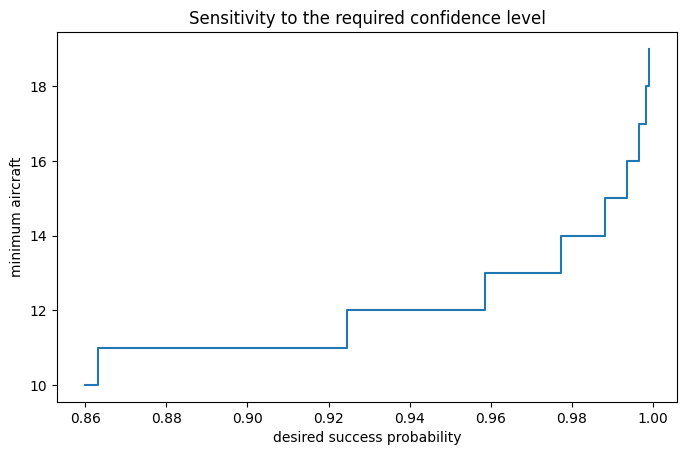

In [6]:
desired = np.linspace(0.86, 0.999, 180)
required = []
for target in desired:
    for N in range(1, 80):
        if mission_success(N) > target:
            required.append(N)
            break

plt.step(desired, required, where="post")
plt.xlabel("desired success probability")
plt.ylabel("minimum aircraft")
plt.title("Sensitivity to the required confidence level")
plt.show()


## 9.4 Particle tracking with spatially varying drift

A particle approximation to diffusion with drift uses

\[
X_{n+1}=X_n+v(X_n)\Delta t+\sqrt{D\Delta t}\,Z_n.
\]

Here the wind increases linearly from 3 km/h at the release point to 8 km/h at the town ten kilometers away.


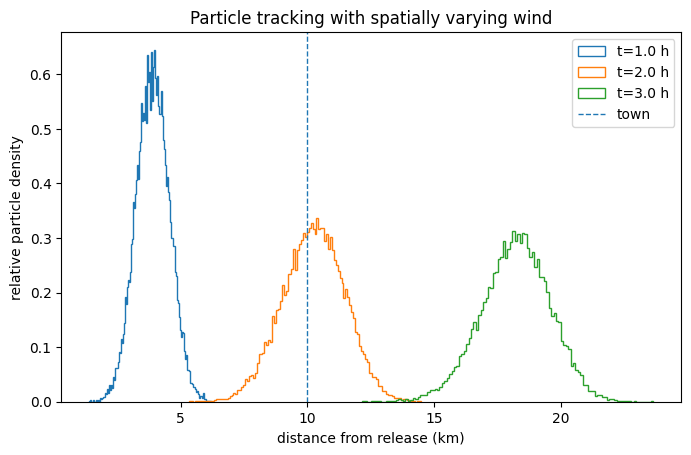

In [7]:
def simulate_particles(number=20_000, final_time=3.0, steps=300, diffusivity=0.25, variable_wind=True):
    dt = final_time / steps
    position = np.zeros(number)
    snapshots = {}
    targets = {int(steps / 3), int(2 * steps / 3), steps}
    for step in range(1, steps + 1):
        if variable_wind:
            velocity = np.clip(3 + 0.5 * position, 3, 8)
        else:
            velocity = np.full(number, 3.0)
        position += velocity * dt + np.sqrt(diffusivity * dt) * rng.standard_normal(number)
        if step in targets:
            snapshots[step * dt] = position.copy()
    return snapshots

variable_snapshots = simulate_particles(variable_wind=True)
constant_snapshots = simulate_particles(variable_wind=False)

for time, positions in variable_snapshots.items():
    plt.hist(positions, bins=120, density=True, histtype="step", label=f"t={time:.1f} h")
plt.axvline(10, linestyle="--", linewidth=1, label="town")
plt.xlabel("distance from release (km)")
plt.ylabel("relative particle density")
plt.title("Particle tracking with spatially varying wind")
plt.legend()
plt.show()


## 9.5 Fractional diffusion and heavy-tailed jumps

For the groundwater example, the chapter uses centered power-law jumps with \(\alpha=1.1\), scale \(A=0.0131\), and drift \(v=0.12\) m/day. The particle cloud spreads like \(t^{1/\alpha}\), much faster than the classical \(t^{1/2}\) law.


In [8]:
def fractional_particle_tracking(
    number_particles=10_000,
    final_time=4_000.0,
    steps=100,
    alpha=1.1,
    scale=0.0131,
    velocity=0.12,
    total_mass=540.0,
):
    dt = final_time / steps
    positions = np.zeros(number_particles)
    times = np.arange(1, steps + 1) * dt
    concentration = np.zeros(steps)
    centering = scale ** (1 / alpha) * alpha / (alpha - 1)
    for j in range(steps):
        u = np.clip(rng.random(number_particles), 0, 1 - np.finfo(float).eps)
        jumps = (scale / (1 - u)) ** (1 / alpha) - centering
        positions += velocity * dt + dt ** (1 / alpha) * jumps
        concentration[j] = total_mass * np.mean((positions > 15) & (positions <= 25)) / 10
    return times, concentration, positions

frac_time, frac_concentration, final_positions = fractional_particle_tracking()
peak_index = int(np.argmax(frac_concentration))
peak_time = frac_time[peak_index]
peak_concentration = frac_concentration[peak_index]
above_safe = np.flatnonzero(frac_concentration > 2.0)
safe_again = frac_time[above_safe[-1]] + (frac_time[1] - frac_time[0]) if len(above_safe) else 0.0

fractional_summary = pd.Series({
    "peak concentration (Ci)": peak_concentration,
    "time of peak (days)": peak_time,
    "safe again, upper step estimate (days)": safe_again,
    "median final particle position (m)": np.median(final_positions),
    "maximum final particle position (m)": np.max(final_positions),
})
display(fractional_summary.to_frame("value"))


,value
peak concentration (Ci),8.958600
time of peak (days),880.000000
"safe again, upper step estimate (days)",2800.000000
median final particle position (m),137.123108
maximum final particle position (m),175698.474245


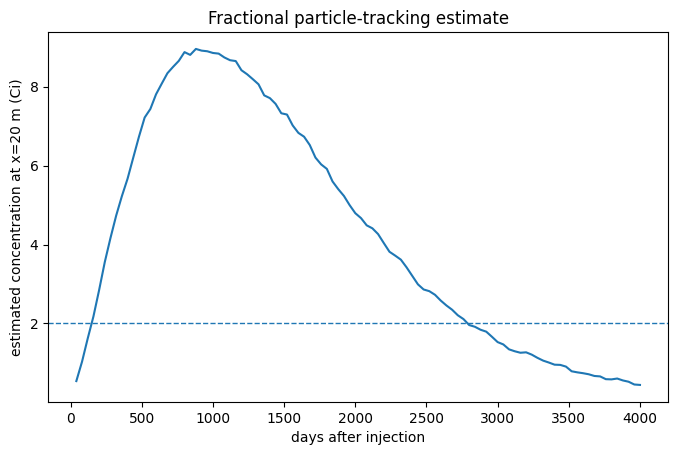

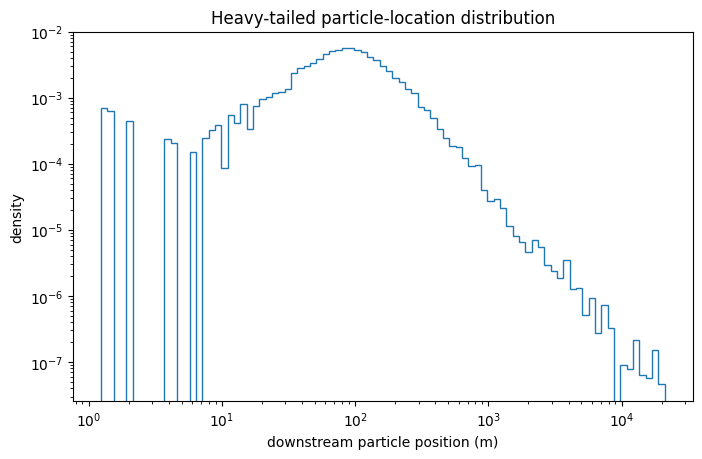

In [9]:
plt.plot(frac_time, frac_concentration)
plt.axhline(2, linestyle="--", linewidth=1)
plt.xlabel("days after injection")
plt.ylabel("estimated concentration at x=20 m (Ci)")
plt.title("Fractional particle-tracking estimate")
plt.show()

# Show the heavy leading tail on a log scale.
positive = final_positions[final_positions > 0]
plt.hist(positive, bins=np.geomspace(max(1e-2, positive.min()), np.quantile(positive, 0.999), 90), density=True, histtype="step")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("downstream particle position (m)")
plt.ylabel("density")
plt.title("Heavy-tailed particle-location distribution")
plt.show()


## Chapter checkpoint

Monte Carlo estimates improve only at the slow \(n^{-1/2}\) rate. Analytic simulation is faster when the probability structure can be summed directly. Particle tracking connects stochastic paths to PDE solutions, while heavy-tailed jumps lead naturally to fractional diffusion and anomalous spreading.
